# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [2]:
# Import necessary libraries
import os
import pathlib
from pathlib import Path

# Data manipulation libraries for handling and processing data
import pandas as pd
import numpy as np

# Visualization libraries for plotting and data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Tensorflow library for building and training neural networks
import tensorflow as tf
from tensorflow.keras import layers

# Scikit-learn library for machine learning tasks
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer

# Image processing library for handling image data
from PIL import Image

# Natural Language Toolkit (NLTK) library for text processing and analysis
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
# Download necessary NLTK resources for text processing
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Regular expressions library for pattern matching and text manipulation
import re

import ast
from collections import Counter

# Set random seeds for reproducibility
import random
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

# Your code here

In [4]:
# Load original JPG files without resizing (RealWaste dataset)
dataset_dir = "/workspace/Learning/Summative lab - NNs and Similar Models/realwaste/realwaste-main/RealWaste"
image_paths = sorted(Path(dataset_dir).rglob("*.jpg"))

# A for loop to extract image information and store it in a list of dictionaries
records = []
for path in image_paths:
    class_name = path.parent.name
    file_size = path.stat().st_size
    with Image.open(path) as img:
        width, height = img.size
        mode = img.mode
        quality = img.info.get("quality")  # may be None for many JPEGs
        records.append({
            "path": str(path),
            "class": class_name,
            "width": width,
            "height": height,
            "aspect_ratio": round(width / height, 3),
            "mode": mode,
            "quality": quality,
            "file_size_bytes": file_size
        })

image_info_df = pd.DataFrame(records)

# Summary statistics for resolution and file size
image_info_df["resolution"] = image_info_df["width"] * image_info_df["height"]
image_info_df.describe()[["width", "height", "aspect_ratio", "file_size_bytes", "resolution"]]

,width,height,aspect_ratio,file_size_bytes,resolution
count,4752.0,4752.0,4752.0,4752.000000,4752.0
mean,524.0,524.0,1.0,144846.038300,274576.0
std,0.0,0.0,0.0,40677.713584,0.0
min,524.0,524.0,1.0,48835.000000,274576.0
25%,524.0,524.0,1.0,113532.750000,274576.0
50%,524.0,524.0,1.0,136988.000000,274576.0
75%,524.0,524.0,1.0,178184.750000,274576.0
max,524.0,524.0,1.0,248649.000000,274576.0


From the above output, here is the observation:
1. There are 4752 images in total.
2. All images are JPG files.
3. All images have a resolusion of 524 by 524 meaning that is has an aspect ration of 1.
4. The file size of the images varies from image to image.

In [5]:
# Loading the dataset
data = tf.keras.utils.image_dataset_from_directory(
    "/workspace/Learning/Summative lab - NNs and Similar Models/realwaste/realwaste-main/RealWaste",          # path to dataset
    image_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 4752 files belonging to 9 classes.


There are 4752 JPG files which are divided into 9 classes/folders

In [6]:
# Viewing the class names
class_names = data.class_names
class_names

['Cardboard',
 'Food Organics',
 'Glass',
 'Metal',
 'Miscellaneous Trash',
 'Paper',
 'Plastic',
 'Textile Trash',
 'Vegetation']

The names of the classes/foldes found are in the output above.

They are Cardboard, Food Organics, Glass, Metal, Miscellaneous Trash, Paper, Plastic, Textile Trash and Vegetation.

In [8]:
# Counting the number of images in each class to check for class imbalance
class_counts = {}
dataset_dir = dataset_dir

# Counting the number of images in each class
for class_name in class_names:
    folder = os.path.join(dataset_dir, class_name)
    class_counts[class_name] = len(os.listdir(folder))

class_counts

{'Cardboard': 461,
 'Food Organics': 411,
 'Glass': 420,
 'Metal': 790,
 'Miscellaneous Trash': 495,
 'Paper': 500,
 'Plastic': 921,
 'Textile Trash': 318,
 'Vegetation': 436}

The following is the image count for each class:

|Class|No.of images|
| :--- | ---: |
|Cardboard|461|
|Food Organics|411|
|Glass|420|
|Metal|790|
|Miscellaneous Trash|495|
|Paper|500|
|Plastic|921|
|Textile Trash|318|
|Vegetation|436|

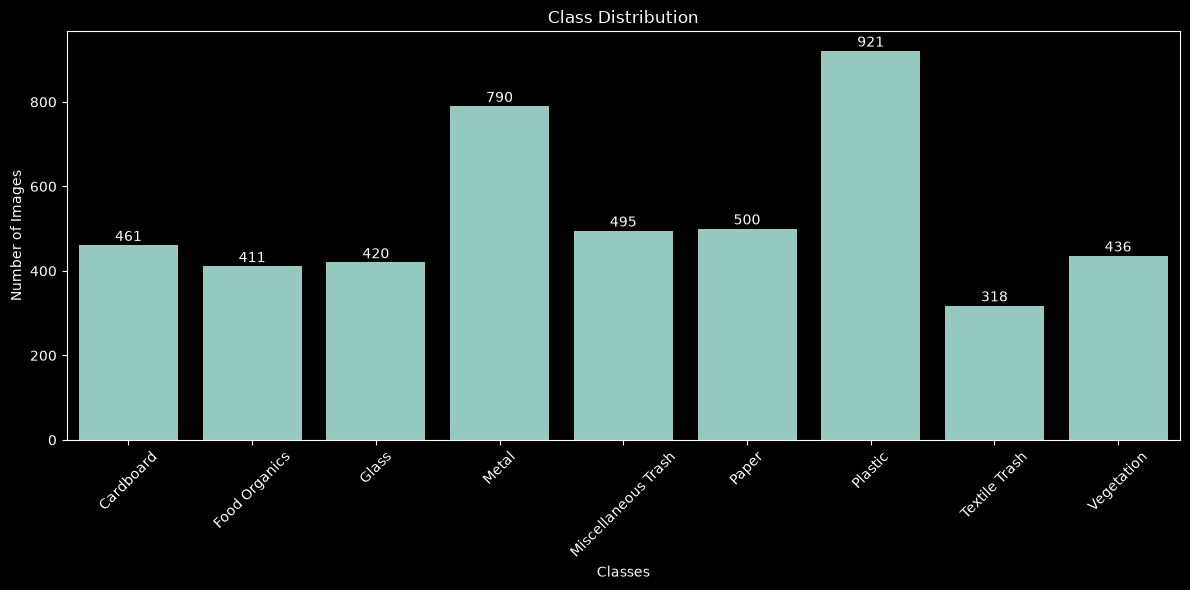

In [9]:
# Plotting the class distribution
plt.style.use("dark_background") # Set dark background style for the plot
plt.figure(figsize=(12,6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

# Adding counts on top of the bars
for i, count in enumerate(class_counts.values()):
    plt.text(i, count + 10, str(count), ha='center')

plt.tight_layout()
plt.show()

The class distribution of the classes is imbalanced.

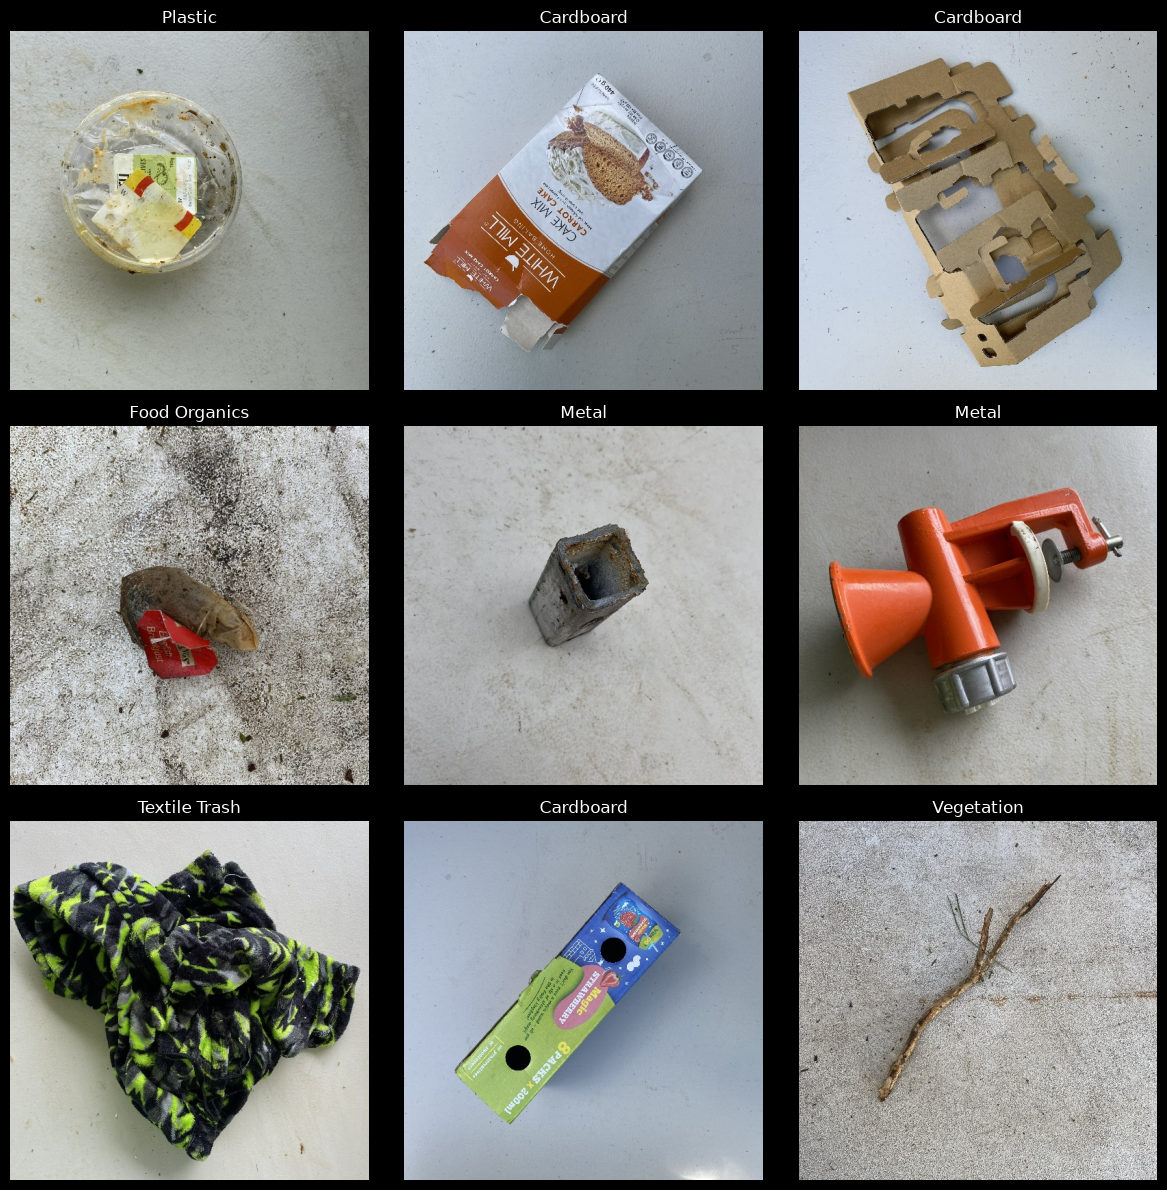

In [11]:
# Displaying a random sample of images from the dataset
sample_paths = random.sample(image_paths, 9)

plt.style.use("dark_background")
plt.figure(figsize=(12, 12))
for i, path in enumerate(sample_paths):
    with Image.open(path) as img:
        ax = plt.subplot(3, 3, i + 1)
        ax.imshow(img)
        ax.set_title(path.parent.name)
        ax.axis("off")

plt.tight_layout()
plt.show()

Above are samples of the images from realwaste dataset.

### Findings about realwaste dataset
1. There are **4752** items in the dataset which are **JPG** file.
2. There are **9** classes in the dataset
3. Below is the names and their counts in the dataset:

    |Class Name|No.of items|
    | :--- | ---: |
    |Cardboard|461|
    |Food Organics|411|
    |Glass|420|
    |Metal|790|
    |Miscellaneous Trash|495|
    |Paper|500|
    |Plastic|921|
    |Textile Trash|318|
    |Vegetation|436|

4. The dataset is not evenly distributed.
5. The resolution of all images are 524 by 524 pixels with a 1.0 aspect ratio.
6. The background looks like it was taken in a facility since the objects in the images are isolated.
7. The lightin g quality looks bright since the objects can be clearly seen in the images.

### 1.2 Explore Text Datasets

#### 1.2.1 Exploring waste_descriptions.csv

In [ ]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# Your code here

In [14]:
# Loading dataset (waste_descriptions.csv)
waste_df = pd.read_csv("waste_descriptions.csv")
waste_df.head()

,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...


It appers that the data in this dataset are text data and common_confusion has missing data.

In [15]:
# Checking the shape of the dataset
waste_df.shape

(5000, 5)

It has 5000 rows and 5 columns

In [16]:
# Checking the structure of the dataset
waste_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   description           5000 non-null   str  
 1   category              5000 non-null   str  
 2   disposal_instruction  5000 non-null   str  
 3   common_confusion      2496 non-null   str  
 4   material_composition  5000 non-null   str  
dtypes: str(5)
memory usage: 195.4 KB


It apperes that common_cofusion indeed has missing data

In [17]:
# Analysising vocabulary and structure
# Checking for missing values
waste_df.isnull().sum()

description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64

There are missing data in common_confusion column.

Going through the dataset, this just explains common misstakes and confusion made when handling the recycling of the materials.

In [18]:
# Checking the data types
waste_df.dtypes

description             str
category                str
disposal_instruction    str
common_confusion        str
material_composition    str
dtype: object

All columns in the dataset are string datatypes

In [19]:
# vocabulary size
vocabulary_size = len(set(" ".join(waste_df['description'].dropna()).split()))
vocabulary_size

305

There are 305 unique words in description column

Text(0, 0.5, 'Frequency')

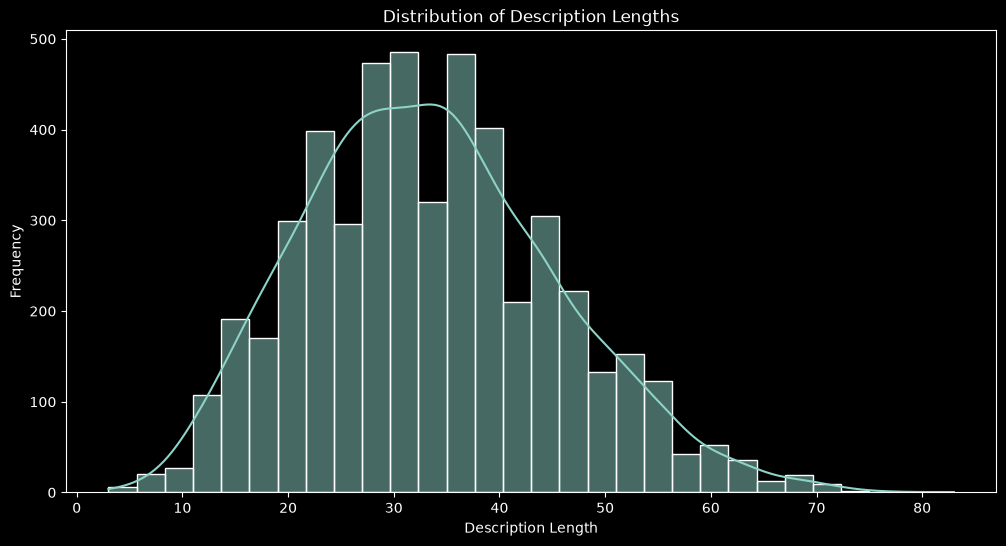

In [20]:
# plotting the distribution of description lengths
description_lengths = waste_df["description"].dropna().apply(len)

plt.style.use("dark_background")
plt.figure(figsize=(12, 6))
sns.histplot(description_lengths, bins=30, kde=True)
plt.title("Distribution of Description Lengths")
plt.xlabel("Description Length")
plt.ylabel("Frequency")

The distribution of the discription lengh looks a bit positively skewed (leans to the left).

In [21]:
# Distribution of categories
category_counts = waste_df['category'].value_counts()
category_counts

category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64

There are 9 categories just like the realwaste dataset.

Here is the categories and their counts

|Category name|No.of items|
| :--- | ---: |
|Vegetation|600|
|Textile Trash|586|
|Cardboard|584|
|Miscellaneous Trash|578|
|Plastic|569|
|Glass|551|
|Food Organics|518|
|Metal|508|
|Paper|506|

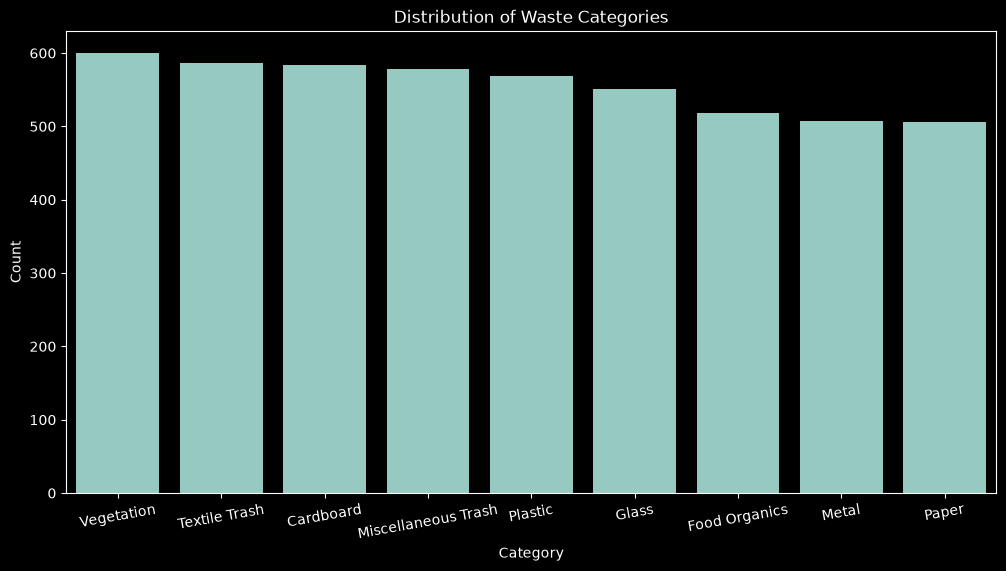

In [22]:
# plot of the distribution of categories
plt.style.use("dark_background")
plt.figure(figsize=(12,6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.xticks(rotation=10)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Distribution of Waste Categories')
plt.show()

The distribution of categories is relatively even.

In [24]:
# Creating a copy of waste_descriptions.csv in order to conduct further analysis without altering the original dataset
waste_df_copy = waste_df.copy()

# Clean descriptions and normalize text
descriptions = (
    waste_df_copy["description"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [25]:
# Top single words
unigram_vectorizer = CountVectorizer(
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z0-9]{3,}\b",
    lowercase=True,
    vocabulary=None
)

X_uni = unigram_vectorizer.fit_transform(descriptions)
uni_counts = X_uni.toarray().sum(axis=0)
unigrams = sorted(
    zip(unigram_vectorizer.get_feature_names_out(), uni_counts),
    key=lambda x: x[1],
    reverse=True,
)[:25]

# Creating a DataFrame for unigrams to visualize the top 25 unigrams
unigrams_df = pd.DataFrame(unigrams, columns=["word", "count"])

# Filter out generic words from unigrams
filtered_unigrams = [
    (word, count)
    for word, count in unigrams
    if word not in stopwords.words("english")
]

print("Top common words:")
for word, count in filtered_unigrams[:20]:
    print(f"{word}: {count}")

Top common words:
sized: 534
glass: 424
bottle: 342
food: 316
paper: 316
box: 313
residue: 309
plastic: 280
metal: 270
brand: 247
dry: 211
new: 196
crumpled: 189
soiled: 189
medium: 187
orange: 186
stained: 185
broken: 184
intact: 184
patterned: 184


In [26]:
# Top bigrams
bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    token_pattern=r"(?u)\b[a-zA-Z0-9]{3,}\b",
    lowercase=True,
)

X_bi = bigram_vectorizer.fit_transform(descriptions)
bi_counts = X_bi.toarray().sum(axis=0)
bigrams = sorted(
    zip(bigram_vectorizer.get_feature_names_out(), bi_counts),
    key=lambda x: x[1],
    reverse=True,
)[:25]

# Creating a DataFrame for bigrams to visualize the top 25 bigrams
bigrams_df = pd.DataFrame(bigrams, columns=["bigram", "count"])

print("\nTop common phrases:")
for phrase, count in bigrams[:20]:
    print(f"{phrase}: {count}")


Top common phrases:
partially filled: 182
fun sized: 179
travel sized: 178
regular sized: 177
food residue: 169
product remaining: 161
multi colored: 160
eco friendly: 148
containing residue: 140
label attached: 132
liquid inside: 128
glass bottle: 62
clamshell packaging: 41
carpet piece: 39
food packaging: 39
glass sheet: 39
linen cloth: 39
avocado pit: 38
metal cutlery: 38
paper roll: 38


#### Findings after exploring waste_descriptions.csv file
1. The dataset has **5000** rows and **5** columns.
2. **common_confusion** column has **2504** missing data.
3. There are **9** categories just like the realwaste dataset.
4. The categories are **evenly distributed** and below is the category and their counts:

    |Category name|No.of items|
    | :--- | ---: |
    |Vegetation|600|
    |Textile Trash|586|
    |Cardboard|584|
    |Miscellaneous Trash|578|
    |Plastic|569|
    |Glass|551|
    |Food Organics|518|
    |Metal|508|
    |Paper|506|
5. The datatypes of all the columns are **string**.
6. The distribution of the discription lengh looks a bit positively skewed.
7. The top 3 common words are sized, glass and bottle and the 3 common phrases(bigrams) are partially filled, fun sized and travel sized.

#### 1.2.2 Exploring waste_policy_documents.json

In [ ]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.json
# - Understand document organization and language

# Your code here

In [27]:
# Loading dataset (waste_policy_documents.csv)
policy_df = pd.read_json("waste_policy_documents.json")
policy_df.head()

,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...,Metro City


It looks like there is integer data, text data and datetime data.

Also the text in categories_covered is enclosed with [] (square brackets). It has to be removed

In [28]:
# Checking the shape of the dataset
policy_df.shape

(14, 6)

The waste_policy_documents.json dataset has 14 rows and 6 columns.

In [29]:
# Checking the datatypes of the dataset
policy_df.dtypes

policy_id              int64
policy_type              str
categories_covered    object
effective_date           str
document_text            str
jurisdiction             str
dtype: object

* category_covered column has text data in it so have to remove the square brackets and change the data-type to str.
* effective_date column has date data and the data-type has to be changed to datetime.
* The rest of the columns in the dataset has the correct data-types.

In [30]:
# Checking for missing values
policy_df.isnull().sum()

policy_id             0
policy_type           0
categories_covered    0
effective_date        0
document_text         0
jurisdiction          0
dtype: int64

There are no missing values

In [31]:
# Creating a copy of waste_policy_documents.csv in order to conduct further analysis without altering the original dataset
policy_df_copy = policy_df.copy()

# Clean descriptions and normalize text
descriptions1 = (
    policy_df_copy["categories_covered"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [32]:
# Calculate word and character counts for each document_text
policy_df_copy["doc_word_count"] = policy_df_copy["document_text"].str.split().str.len()
policy_df_copy["doc_char_count"] = policy_df_copy["document_text"].str.len()

# Displaying document_text length statistics
print("Document length statistics:")
policy_df_copy[["doc_word_count", "doc_char_count"]].describe()

Document length statistics:


,doc_word_count,doc_char_count
count,14.000000,14.000000
mean,101.785714,682.857143
std,15.115853,92.686284
min,86.000000,571.000000
25%,94.250000,635.750000
50%,99.000000,666.500000
75%,102.000000,687.500000
max,146.000000,951.000000


The average document text word count is 101 and character count is 682.

In [33]:
# Top single words
unigram_vectorizer = CountVectorizer(
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z0-9]{3,}\b",
    lowercase=True,
    vocabulary=None
)

X_uni = unigram_vectorizer.fit_transform(descriptions1)
uni_counts = X_uni.toarray().sum(axis=0)
unigrams = sorted(
    zip(unigram_vectorizer.get_feature_names_out(), uni_counts),
    key=lambda x: x[1],
    reverse=True,
)[:25]

# Creating a DataFrame for unigrams to visualize the top 25 unigrams
unigrams_df = pd.DataFrame(unigrams, columns=["word", "count"])

# Filter out generic words from unigrams
filtered_unigrams = [
    (word, count)
    for word, count in unigrams
    if word not in stopwords.words("english")
]

print("Top common words:")
for word, count in filtered_unigrams[:20]:
    print(f"{word}: {count}")

Top common words:
trash: 7
metal: 4
miscellaneous: 4
vegetation: 4
cardboard: 3
glass: 3
plastic: 3
textile: 3
food: 2
organics: 2
paper: 1


In [34]:
# Top bigrams
bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    token_pattern=r"(?u)\b[a-zA-Z0-9]{3,}\b",
    lowercase=True,
)

X_bi = bigram_vectorizer.fit_transform(descriptions1)
bi_counts = X_bi.toarray().sum(axis=0)
bigrams = sorted(
    zip(bigram_vectorizer.get_feature_names_out(), bi_counts),
    key=lambda x: x[1],
    reverse=True,
)[:25]

# Creating a DataFrame for bigrams to visualize the top 25 bigrams
bigrams_df = pd.DataFrame(bigrams, columns=["bigram", "count"])

print("\nTop common phrases:")
for phrase, count in bigrams[:20]:
    print(f"{phrase}: {count}")


Top common phrases:
miscellaneous trash: 4
textile trash: 3
food organics: 2
trash vegetation: 2
cardboard glass: 1
cardboard vegetation: 1
glass miscellaneous: 1
glass textile: 1
metal glass: 1
metal miscellaneous: 1
metal textile: 1
organics metal: 1
plastic metal: 1
plastic miscellaneous: 1
vegetation metal: 1


#### Findings after exploring waste_policy_documents.json
1. The dataset has **14** rows and **5** columns.
2. There are **0** missing data.
3. There are **14** policies.
4. policy_id is integer, policy_type is string, categories_covered is object although can be set to string after removing square brackets, effective_date is string although should be datetime since the data found there is in date format, document_text and jurisdiction are string datatypes.
5. This dataset is short since it only has 14 rows and 6 columns.

### 1.3 Create Data Pipelines

#### 1.3.1 Image pipeline

In [35]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path('RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 1
Class names: ['realwaste-main']
Total images found: 0
Found 4752 files belonging to 1 classes.
Using 3802 files for training.
Found 4752 files belonging to 1 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


The dataset is split **80%** for training, **10%** for validation and **10%** for testing. this means that out of the total images that is **4752** images, **3802** images are used for training and **475** images for testing and validation.

In [ ]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

# Your code here

#### 1.3.2 Text Preprocessing pipeline



In [37]:
# Define a lemmatizer and stop words for text preprocessing
LEMMATIZER = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words("english"))

# Define a function to clean text data
def clean_text(text):
    """Lowercase, strip punctuation/digits, tokenize, remove stopwords, lemmatize."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

# Apply the cleaning function to the 'description' column in the waste_df DataFrame
waste_df["clean_description"] = waste_df["description"].apply(clean_text)
# Display the first few rows of the DataFrame to verify the cleaning process
waste_df[["description", "clean_description", "category"]].head()

,description,clean_description,category
0,soiled silver tablecloth,soiled silver tablecloth,Textile Trash
1,folded glass bottle leaking,folded glass bottle leaking,Glass
2,large Supermarket vegetable waste with food re...,large supermarket vegetable waste food residue,Food Organics
3,intact floral carpet piece,intact floral carpet piece,Textile Trash
4,empty fun-sized purple apple core,empty fun sized purple apple core,Food Organics


In [38]:
# Stratified train / validation / test split for the text classifier
X_temp, X_test_text, y_temp, y_test_text = train_test_split(
    waste_df["clean_description"], waste_df["category"],
    test_size=0.15, stratify=waste_df["category"], random_state=42
)
X_train_text, X_val_text, y_train_text, y_val_text = train_test_split(
    X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train_text)} | Val: {len(X_val_text)} | Test: {len(X_test_text)}")
print("\nClass balance check (train):")
print(y_train_text.value_counts(normalize=True).round(3))

Train: 3612 | Val: 638 | Test: 750

Class balance check (train):
category
Vegetation             0.120
Textile Trash          0.117
Cardboard              0.117
Miscellaneous Trash    0.115
Plastic                0.114
Glass                  0.110
Food Organics          0.104
Metal                  0.102
Paper                  0.101
Name: proportion, dtype: float64


**Steps taken in preprocessing**
1. Making all text to be lowercase.
2. Removing special characters and numbers if any.
3. Word tokenize the text basically splitting the text into individual words.
4. Lemmatizing the text basically keeping the tokens human-readable while still normalizing plurals or verb forms.
5. Stratified splitting of the data into 70% training, 15% testing and 15% testing.

#### 1.3.3 Preparing document for RAG

In [ ]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

# Your code here

In [40]:
policy_df.columns

Index(['policy_id', 'policy_type', 'categories_covered', 'effective_date',
       'document_text', 'jurisdiction'],
      dtype='str')

In [41]:
def clean_doc_text(text):
    text = re.sub(r"\s+", " ", text).strip()
    return text

policy_df["document_text_clean"] = policy_df["document_text"].apply(clean_doc_text)

# Chunk each policy document into sentence-level passages for finer-grained retrieval
def chunk_document(row):
    sentences = nltk.sent_tokenize(row["document_text_clean"])
    chunks = []
    for i, sent in enumerate(sentences):
        chunks.append({
            "doc_id": row.get("doc_id", row["category"]),
            "category": row["category"],
            "title": row.get("title", f"Policy: {row['category']}"),
            "chunk_id": f"{row.get('doc_id', row['category'])}-{i}",
            "text": sent,
        })
    return chunks

all_chunks = []
for _, row in policy_df.iterrows():
    all_chunks.extend(chunk_document(row))
chunks_df = pd.DataFrame(all_chunks)
print(f"Policy documents: {len(policy_df)} -> retrieval chunks: {len(chunks_df)}")
chunks_df.head(10)

KeyError: 'category'

## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [ ]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

# Your code here

### 2.2 Implement CNN Model with Transfer Learning

In [ ]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here

### 2.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics

# Your code here

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 2.4 Fine-tune the Model

In [ ]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# Your code here

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [ ]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# Your code here

### 3.2 Implement Text Classification Model

In [ ]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Your code here

### 3.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

# Your code here

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 3.4 Create Classification Function

In [ ]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # Your code here
    pass

## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [ ]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

### 4.2 Implement RAG-based System

In [ ]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here

### 4.3 Adjust and Evaluate the System

In [ ]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

In [ ]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here

### 4.4 Create Instruction Generation Function

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    # Your code here
    pass

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [ ]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Your code here

### 5.2 Implement Integrated Assistant

In [ ]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    # Your code here
    pass

### 5.3 Evaluate the Integrated System

In [ ]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# Your code here

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.